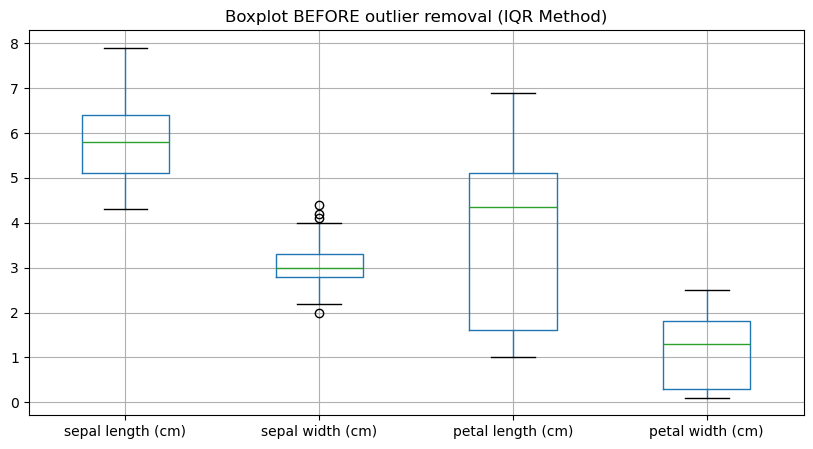

Number of outliers detected: 4
Original samples: 150
Samples after removing outliers: 146


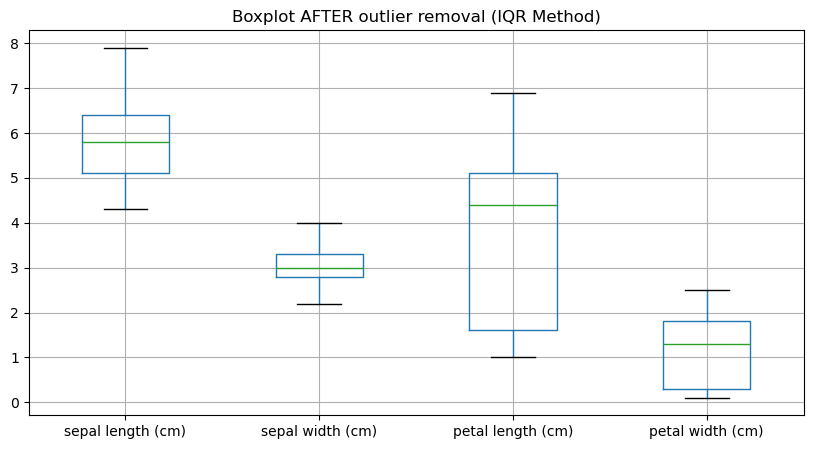

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# -----------------------------
# 1️⃣ Load Iris dataset
# -----------------------------
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# -----------------------------
# 2️⃣ Boxplot BEFORE removal
# -----------------------------
plt.figure(figsize=(10,5))
df.boxplot()
plt.title("Boxplot BEFORE outlier removal (IQR Method)")
plt.show()

# -----------------------------
# 3️⃣ Detect outliers using IQR
# -----------------------------
outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns)

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # True = this sample is an outlier for this feature
    outlier_mask[col] = (df[col] < lower_bound) | (df[col] > upper_bound)

# A row is an outlier if ANY feature is flagged
combined_outliers = outlier_mask.any(axis=1)

print("Number of outliers detected:", combined_outliers.sum())

# -----------------------------
# 4️⃣ Remove outliers
# -----------------------------
df_clean = df[~combined_outliers]

print("Original samples:", len(df))
print("Samples after removing outliers:", len(df_clean))

# -----------------------------
# 5️⃣ Boxplot AFTER removal
# -----------------------------
plt.figure(figsize=(10,5))
df_clean.boxplot()
plt.title("Boxplot AFTER outlier removal (IQR Method)")
plt.show()
